# 🩸 Diabetes Dataset - Exploratory Data Analysis

## Multi-Disease AI Healthcare Platform | BTP 2025-2026

---

### 📋 Notebook Overview

This notebook performs comprehensive Exploratory Data Analysis (EDA) on the **Diabetes Health Indicators Dataset** to understand data quality, feature distributions, and preprocessing requirements.

### 🎯 Objectives
1. Understand dataset structure and feature types
2. Identify missing values and their patterns
3. Analyze class distribution (diabetes stages)
4. Detect outliers and anomalies
5. Explore feature correlations
6. Generate preprocessing recommendations for Week 3

### 📊 Dataset Information
- **Source:** Comprehensive Diabetes Health Indicators Dataset
- **Size:** ~100,000 patient records
- **Target:** `diagnosed_diabetes` (0 = No Diabetes, 1 = Diabetes)
- **Features:** Demographics, lifestyle, lab values, medical history

---

**Author:** BTP Project Team  
**Date:** January 27, 2026  
**Week:** 2 - Exploratory Data Analysis

## 1. Setup and Data Loading

In [1]:
# ============================================================================
# IMPORTS AND CONFIGURATION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Add project root to path for imports
import sys
sys.path.insert(0, str(Path.cwd().parent.parent))

# Import our EDA utilities
from src.utils.eda_utils import (
    load_dataset, missing_value_analysis, statistical_summary,
    class_distribution_analysis, distribution_plots, outlier_analysis,
    correlation_analysis, feature_type_analysis, generate_eda_report,
    COLORS
)

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# Paths
DATA_PATH = Path('../../datasets/diabetes_health_indicators.csv')
FIGURES_PATH = Path('./figures/diabetes')
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("✅ Libraries imported successfully!")
print(f"📁 Data path: {DATA_PATH}")
print(f"📁 Figures will be saved to: {FIGURES_PATH}")

✅ Libraries imported successfully!
📁 Data path: ..\..\datasets\diabetes_health_indicators.csv
📁 Figures will be saved to: figures\diabetes


In [2]:
# ============================================================================
# LOAD DATASET
# ============================================================================

df = load_dataset(DATA_PATH)

# Display first few rows
print("\n📋 First 5 rows of the dataset:")
df.head()

📊 DATASET OVERVIEW
📁 File: diabetes_health_indicators.csv
📐 Shape: 100,000 rows × 31 columns
💾 Memory Usage: 55.81 MB
🔢 Numeric Columns: 24
📝 Categorical Columns: 7

📋 First 5 rows of the dataset:


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.700,7.900,7.900,0,0,0,30.500,0.890,134,78,68,239,41,160,145,136,236,6.360,8.180,29.600,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.700,6.500,8.700,0,0,0,23.100,0.800,129,76,67,116,55,50,30,93,150,2.000,5.630,23.000,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.400,10.000,8.100,1,0,0,22.200,0.810,115,73,74,213,66,99,36,118,195,5.070,7.510,44.700,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.400,6.600,5.200,0,0,0,26.800,0.880,120,93,68,171,50,79,140,139,253,5.280,9.030,38.200,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.200,7.400,5.000,0,0,0,21.200,0.780,92,67,67,210,52,125,160,137,184,12.740,7.200,23.500,Type 2,1


In [3]:
# ============================================================================
# COLUMN INFORMATION
# ============================================================================

print("📋 COLUMN DESCRIPTIONS")
print("=" * 80)

column_descriptions = {
    # Demographics
    'age': 'Age in years',
    'gender': 'Gender (Male/Female)',
    'ethnicity': 'Ethnic background (Asian, White, Hispanic, Black, etc.)',
    'education_level': 'Education level (Highschool, College, etc.)',
    'income_level': 'Income bracket (Low, Lower-Middle, Middle, Upper-Middle, High)',
    'employment_status': 'Employment status (Employed, Unemployed, Retired)',
    
    # Lifestyle factors
    'smoking_status': 'Smoking status (Never, Former, Current)',
    'alcohol_consumption_per_week': 'Alcohol drinks per week',
    'physical_activity_minutes_per_week': 'Exercise minutes per week',
    'diet_score': 'Diet quality score (0-10)',
    'sleep_hours_per_day': 'Average sleep hours per day',
    'screen_time_hours_per_day': 'Screen time hours per day',
    
    # Medical history
    'family_history_diabetes': 'Family history of diabetes (0=No, 1=Yes)',
    'hypertension_history': 'History of hypertension (0=No, 1=Yes)',
    'cardiovascular_history': 'History of cardiovascular disease (0=No, 1=Yes)',
    
    # Physical measurements
    'bmi': 'Body Mass Index',
    'waist_to_hip_ratio': 'Waist to hip ratio',
    'systolic_bp': 'Systolic blood pressure (mmHg)',
    'diastolic_bp': 'Diastolic blood pressure (mmHg)',
    'heart_rate': 'Resting heart rate (bpm)',
    
    # Lab values - Lipid panel
    'cholesterol_total': 'Total cholesterol (mg/dL)',
    'hdl_cholesterol': 'HDL (good) cholesterol (mg/dL)',
    'ldl_cholesterol': 'LDL (bad) cholesterol (mg/dL)',
    'triglycerides': 'Triglycerides (mg/dL)',
    
    # Lab values - Diabetes markers (MOST IMPORTANT)
    'glucose_fasting': 'Fasting blood glucose (mg/dL)',
    'glucose_postprandial': 'Post-meal blood glucose (mg/dL)',
    'insulin_level': 'Fasting insulin level',
    'hba1c': 'Hemoglobin A1c (%) - 3-month average glucose',
    
    # Risk scores & targets
    'diabetes_risk_score': 'Calculated diabetes risk score',
    'diabetes_stage': 'Diabetes classification (No Diabetes, Pre-Diabetes, Type 1, Type 2)',
    'diagnosed_diabetes': '🎯 TARGET: Diagnosed with diabetes (0=No, 1=Yes)'
}

for col in df.columns:
    desc = column_descriptions.get(col, 'No description available')
    dtype = df[col].dtype
    print(f"• {col:40} ({str(dtype):8}): {desc}")

📋 COLUMN DESCRIPTIONS
• age                                      (int64   ): Age in years
• gender                                   (object  ): Gender (Male/Female)
• ethnicity                                (object  ): Ethnic background (Asian, White, Hispanic, Black, etc.)
• education_level                          (object  ): Education level (Highschool, College, etc.)
• income_level                             (object  ): Income bracket (Low, Lower-Middle, Middle, Upper-Middle, High)
• employment_status                        (object  ): Employment status (Employed, Unemployed, Retired)
• smoking_status                           (object  ): Smoking status (Never, Former, Current)
• alcohol_consumption_per_week             (int64   ): Alcohol drinks per week
• physical_activity_minutes_per_week       (int64   ): Exercise minutes per week
• diet_score                               (float64 ): Diet quality score (0-10)
• sleep_hours_per_day                      (float64 ): Average sl

## 2. Data Quality Assessment

In [7]:
# ============================================================================
# DATA TYPES AND INFO
# ============================================================================

print("📊 DATA TYPES OVERVIEW")
print("=" * 50)

# Count data types
dtype_counts = df.dtypes.value_counts()
print(f"\nData Type Distribution:")
for dtype, count in dtype_counts.items():
    print(f"   {dtype}: {count} columns")

print(f"\n💾 Total Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

📊 DATA TYPES OVERVIEW

Data Type Distribution:
   int64: 16 columns
   float64: 8 columns
   object: 7 columns

💾 Total Memory Usage: 55.81 MB


In [8]:
# ============================================================================
# MISSING VALUE ANALYSIS
# ============================================================================

missing_stats = missing_value_analysis(df, plot=True, figsize=(14, 5))


🔍 MISSING VALUE ANALYSIS
📊 Total Cells: 3,100,000
❌ Total Missing: 0
📈 Overall Missing Rate: 0.00%
📋 Columns with Missing Values: 0/31

✅ No missing values found in this dataset!


In [9]:
# ============================================================================
# CHECK FOR DUPLICATE RECORDS
# ============================================================================

print("🔍 DUPLICATE ANALYSIS")
print("=" * 50)

duplicates = df.duplicated().sum()
dup_pct = (duplicates / len(df)) * 100

print(f"📋 Total Records: {len(df):,}")
print(f"🔄 Duplicate Records: {duplicates:,} ({dup_pct:.2f}%)")

if duplicates > 0:
    print(f"⚠️  Consider removing duplicates during preprocessing.")
else:
    print(f"✅ No duplicate records found.")

🔍 DUPLICATE ANALYSIS
📋 Total Records: 100,000
🔄 Duplicate Records: 0 (0.00%)
✅ No duplicate records found.


## 3. Statistical Summary

In [10]:
# ============================================================================
# COMPREHENSIVE STATISTICAL SUMMARY
# ============================================================================

stats = statistical_summary(df)
stats


📈 STATISTICAL SUMMARY
📊 Numeric Features: 24
⚠️  Highly Skewed Features (|skew| > 1): 4


,Count,Mean,Std,Min,Q1 (25%),Median,Q3 (75%),Max,Skewness,Kurtosis,IQR
age,100000,50.120,15.605,18.000,39.000,50.000,61.000,90.000,0.083,-0.388,22.000
alcohol_consumption_per_week,100000,2.004,1.418,0.000,1.000,2.000,3.000,10.000,0.703,0.452,2.000
physical_activity_minutes_per_week,100000,118.912,84.410,0.000,57.000,100.000,160.000,833.000,1.390,2.812,103.000
diet_score,100000,5.995,1.781,0.000,4.800,6.000,7.200,10.000,-0.070,-0.220,2.400
sleep_hours_per_day,100000,6.998,1.095,3.000,6.300,7.000,7.700,10.000,-0.013,-0.112,1.400
screen_time_hours_per_day,100000,5.996,2.468,0.500,4.300,6.000,7.700,16.800,0.083,-0.177,3.400
family_history_diabetes,100000,0.219,0.414,0.000,0.000,0.000,0.000,1.000,1.356,-0.161,0.000
hypertension_history,100000,0.251,0.433,0.000,0.000,0.000,1.000,1.000,1.150,-0.678,1.000
cardiovascular_history,100000,0.079,0.270,0.000,0.000,0.000,0.000,1.000,3.116,7.713,0.000
bmi,100000,25.613,3.587,15.000,23.200,25.600,28.000,39.200,0.006,-0.057,4.800


In [11]:
# ============================================================================
# KEY DIABETES MARKERS ANALYSIS
# ============================================================================

print("🩸 DIABETES MARKERS ANALYSIS")
print("=" * 60)

# Normal ranges for diabetes markers
diabetes_markers = {
    'glucose_fasting': {'normal': (70, 100), 'prediabetes': (100, 126), 'diabetes': (126, float('inf'))},
    'hba1c': {'normal': (0, 5.7), 'prediabetes': (5.7, 6.5), 'diabetes': (6.5, float('inf'))},
    'glucose_postprandial': {'normal': (0, 140), 'prediabetes': (140, 200), 'diabetes': (200, float('inf'))}
}

for marker, ranges in diabetes_markers.items():
    if marker in df.columns:
        data = df[marker]
        print(f"\n📊 {marker}:")
        print(f"   Range: {data.min():.1f} - {data.max():.1f}")
        print(f"   Mean: {data.mean():.1f}, Median: {data.median():.1f}")
        
        # Calculate percentages in each range
        normal_pct = ((data >= ranges['normal'][0]) & (data < ranges['normal'][1])).mean() * 100
        prediabetes_pct = ((data >= ranges['prediabetes'][0]) & (data < ranges['prediabetes'][1])).mean() * 100
        diabetes_pct = (data >= ranges['diabetes'][0]).mean() * 100
        
        print(f"   Normal: {normal_pct:.1f}%, Prediabetes: {prediabetes_pct:.1f}%, Diabetes: {diabetes_pct:.1f}%")

🩸 DIABETES MARKERS ANALYSIS

📊 glucose_fasting:
   Range: 60.0 - 172.0
   Mean: 111.1, Median: 111.0
   Normal: 19.6%, Prediabetes: 65.8%, Diabetes: 14.5%

📊 hba1c:
   Range: 4.0 - 9.8
   Mean: 6.5, Median: 6.5
   Normal: 15.6%, Prediabetes: 33.3%, Diabetes: 51.1%

📊 glucose_postprandial:
   Range: 70.0 - 287.0
   Mean: 160.0, Median: 160.0
   Normal: 25.4%, Prediabetes: 64.4%, Diabetes: 10.2%


## 4. Target Variable Analysis


⚖️ CLASS DISTRIBUTION ANALYSIS
🎯 Target Column: diagnosed_diabetes
📊 Number of Classes: 2

📈 Class Distribution:
   • Class 1: 59,998 samples (60.00%)
   • Class 0: 40,002 samples (40.00%)

⚖️ Imbalance Ratio: 1.50:1
✅ Classes are relatively balanced.


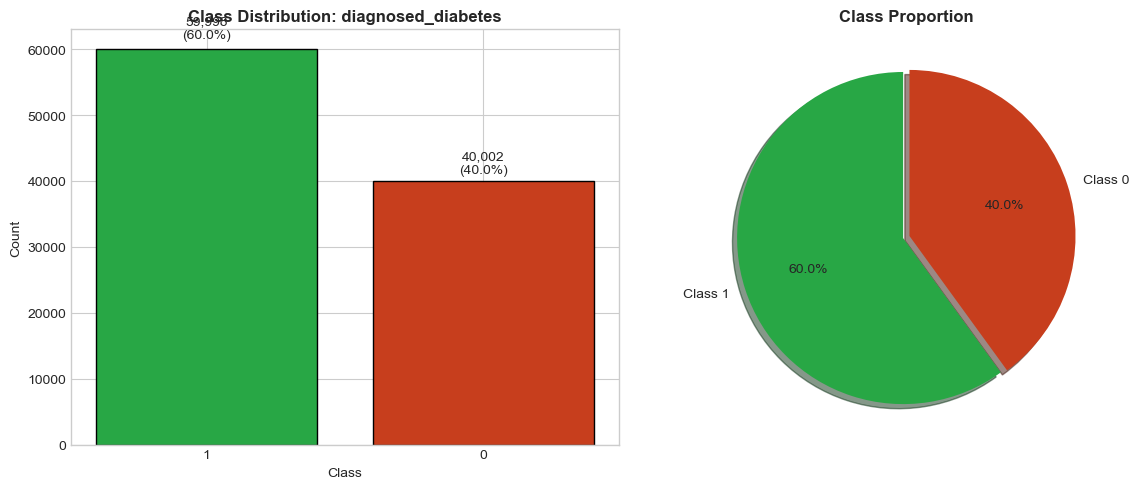


📁 Figure saved to: figures\diabetes\class_distribution.png


<Figure size 640x480 with 0 Axes>

In [4]:
# ============================================================================
# CLASS DISTRIBUTION (TARGET: diagnosed_diabetes)
# ============================================================================

class_info = class_distribution_analysis(df, target_col='diagnosed_diabetes', figsize=(12, 5))

plt.savefig(FIGURES_PATH / 'class_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
print(f"\n📁 Figure saved to: {FIGURES_PATH / 'class_distribution.png'}")

📊 DIABETES STAGE DISTRIBUTION


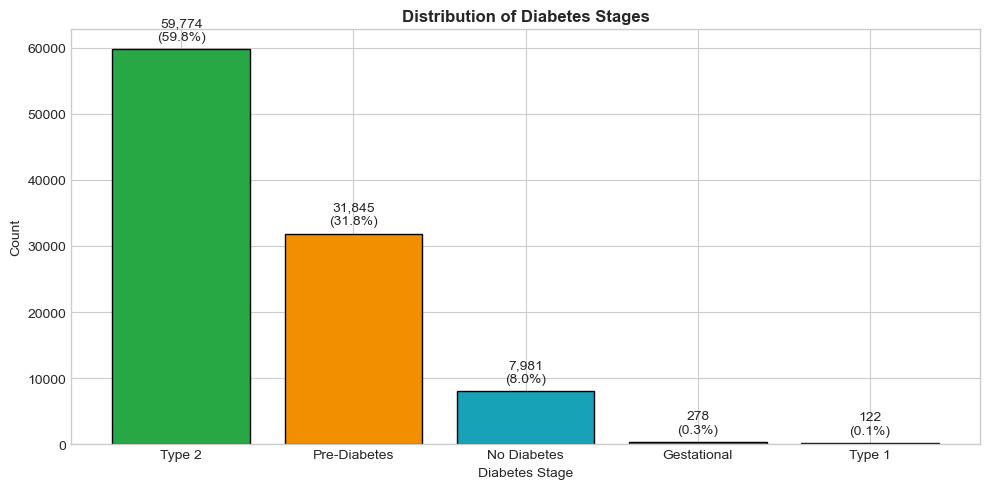


📊 Stage Distribution:
   • Type 2: 59,774 (59.8%)
   • Pre-Diabetes: 31,845 (31.8%)
   • No Diabetes: 7,981 (8.0%)
   • Gestational: 278 (0.3%)
   • Type 1: 122 (0.1%)


In [5]:
# ============================================================================
# DIABETES STAGE DISTRIBUTION (Multi-class insight)
# ============================================================================

print("📊 DIABETES STAGE DISTRIBUTION")
print("=" * 50)

if 'diabetes_stage' in df.columns:
    stage_counts = df['diabetes_stage'].value_counts()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = [COLORS['success'], COLORS['warning'], COLORS['info'], COLORS['danger']]
    bars = ax.bar(stage_counts.index, stage_counts.values, color=colors[:len(stage_counts)], edgecolor='black')
    
    # Add count labels
    for bar, count in zip(bars, stage_counts.values):
        pct = count / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.01,
               f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
    
    ax.set_xlabel('Diabetes Stage')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Diabetes Stages', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / 'diabetes_stages.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print("\n📊 Stage Distribution:")
    for stage, count in stage_counts.items():
        pct = count / len(df) * 100
        print(f"   • {stage}: {count:,} ({pct:.1f}%)")

## 5. Feature Type Analysis

In [12]:
# ============================================================================
# CATEGORIZE FEATURES BY TYPE
# ============================================================================

feature_types = feature_type_analysis(df)


📋 FEATURE TYPE ANALYSIS

📌 CONTINUOUS (19 features):
   age, physical_activity_minutes_per_week, diet_score, sleep_hours_per_day, screen_time_hours_per_day, bmi, waist_to_hip_ratio, systolic_bp, diastolic_bp, heart_rate...

📌 DISCRETE (1 features):
   alcohol_consumption_per_week

📌 BINARY (4 features):
   family_history_diabetes, hypertension_history, cardiovascular_history, diagnosed_diabetes

📌 CATEGORICAL (7 features):
   gender, ethnicity, education_level, income_level, employment_status, smoking_status, diabetes_stage



📊 CATEGORICAL FEATURE DISTRIBUTIONS


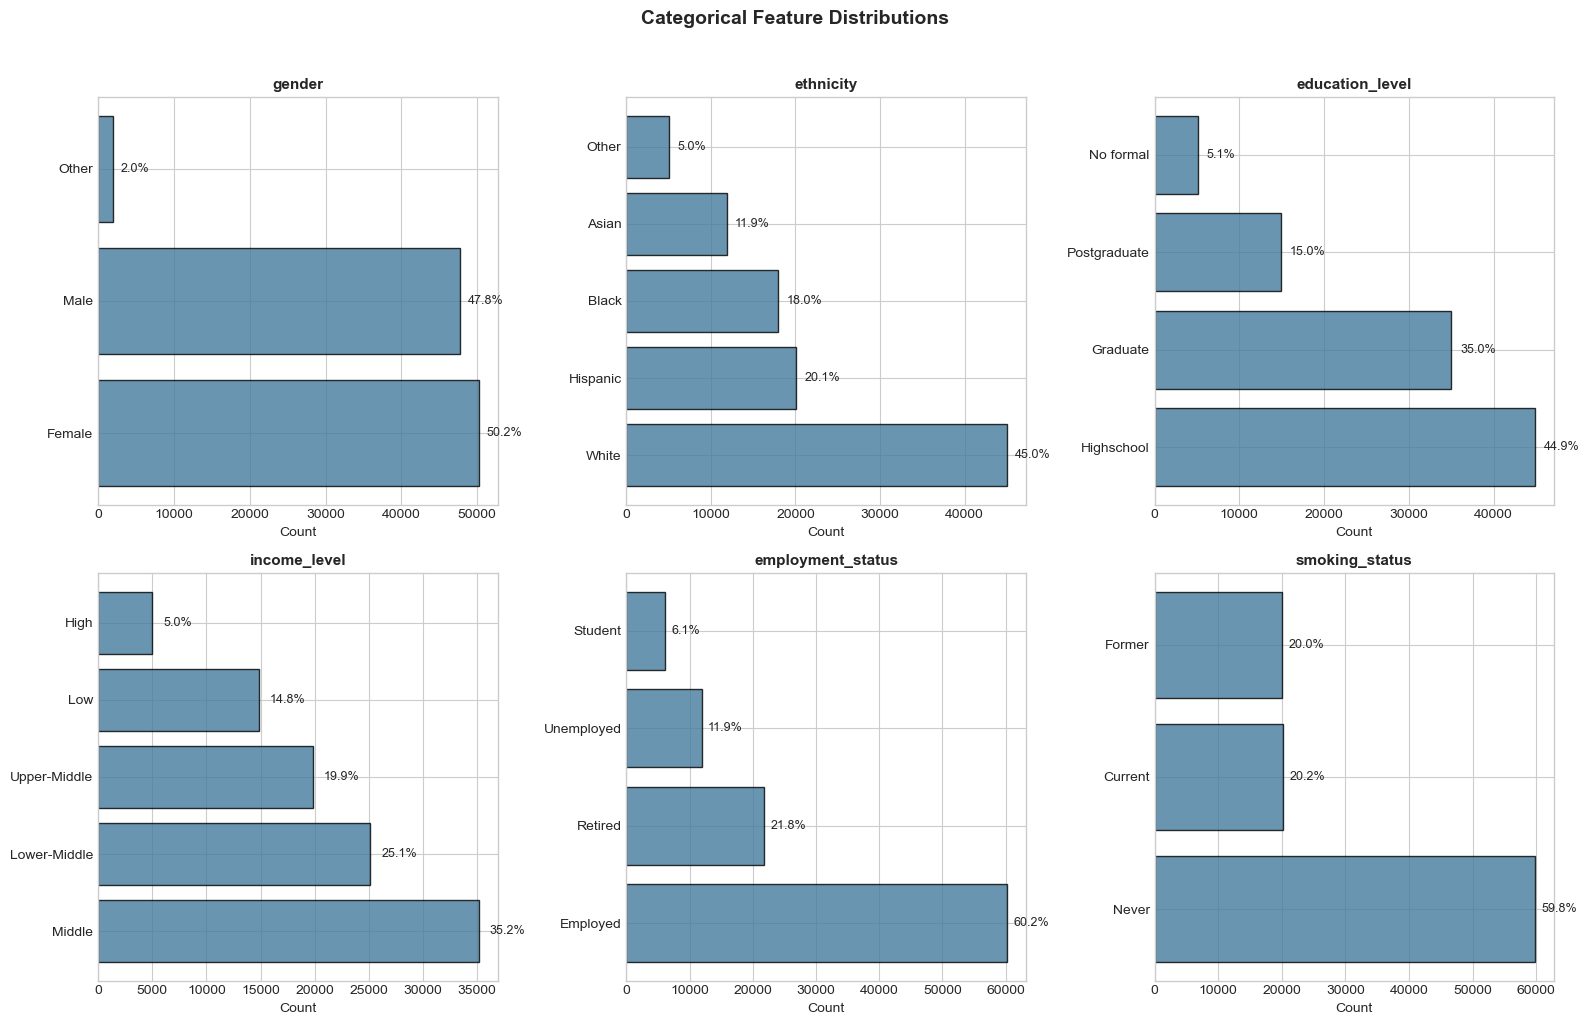

In [13]:
# ============================================================================
# CATEGORICAL FEATURE ANALYSIS
# ============================================================================

print("📊 CATEGORICAL FEATURE DISTRIBUTIONS")
print("=" * 60)

categorical_cols = ['gender', 'ethnicity', 'education_level', 'income_level', 
                    'employment_status', 'smoking_status']

# Filter to existing columns
categorical_cols = [col for col in categorical_cols if col in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]
    value_counts = df[col].value_counts()
    
    # Horizontal bar for better readability
    bars = ax.barh(value_counts.index.astype(str), value_counts.values, 
                   color=COLORS['diabetes'], edgecolor='black', alpha=0.8)
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Count')
    
    # Add percentage labels
    total = len(df)
    for bar, count in zip(bars, value_counts.values):
        pct = count / total * 100
        ax.text(count + total*0.01, bar.get_y() + bar.get_height()/2,
               f'{pct:.1f}%', ha='left', va='center', fontsize=9)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'categorical_distributions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6. Continuous Feature Distributions


📊 FEATURE DISTRIBUTIONS


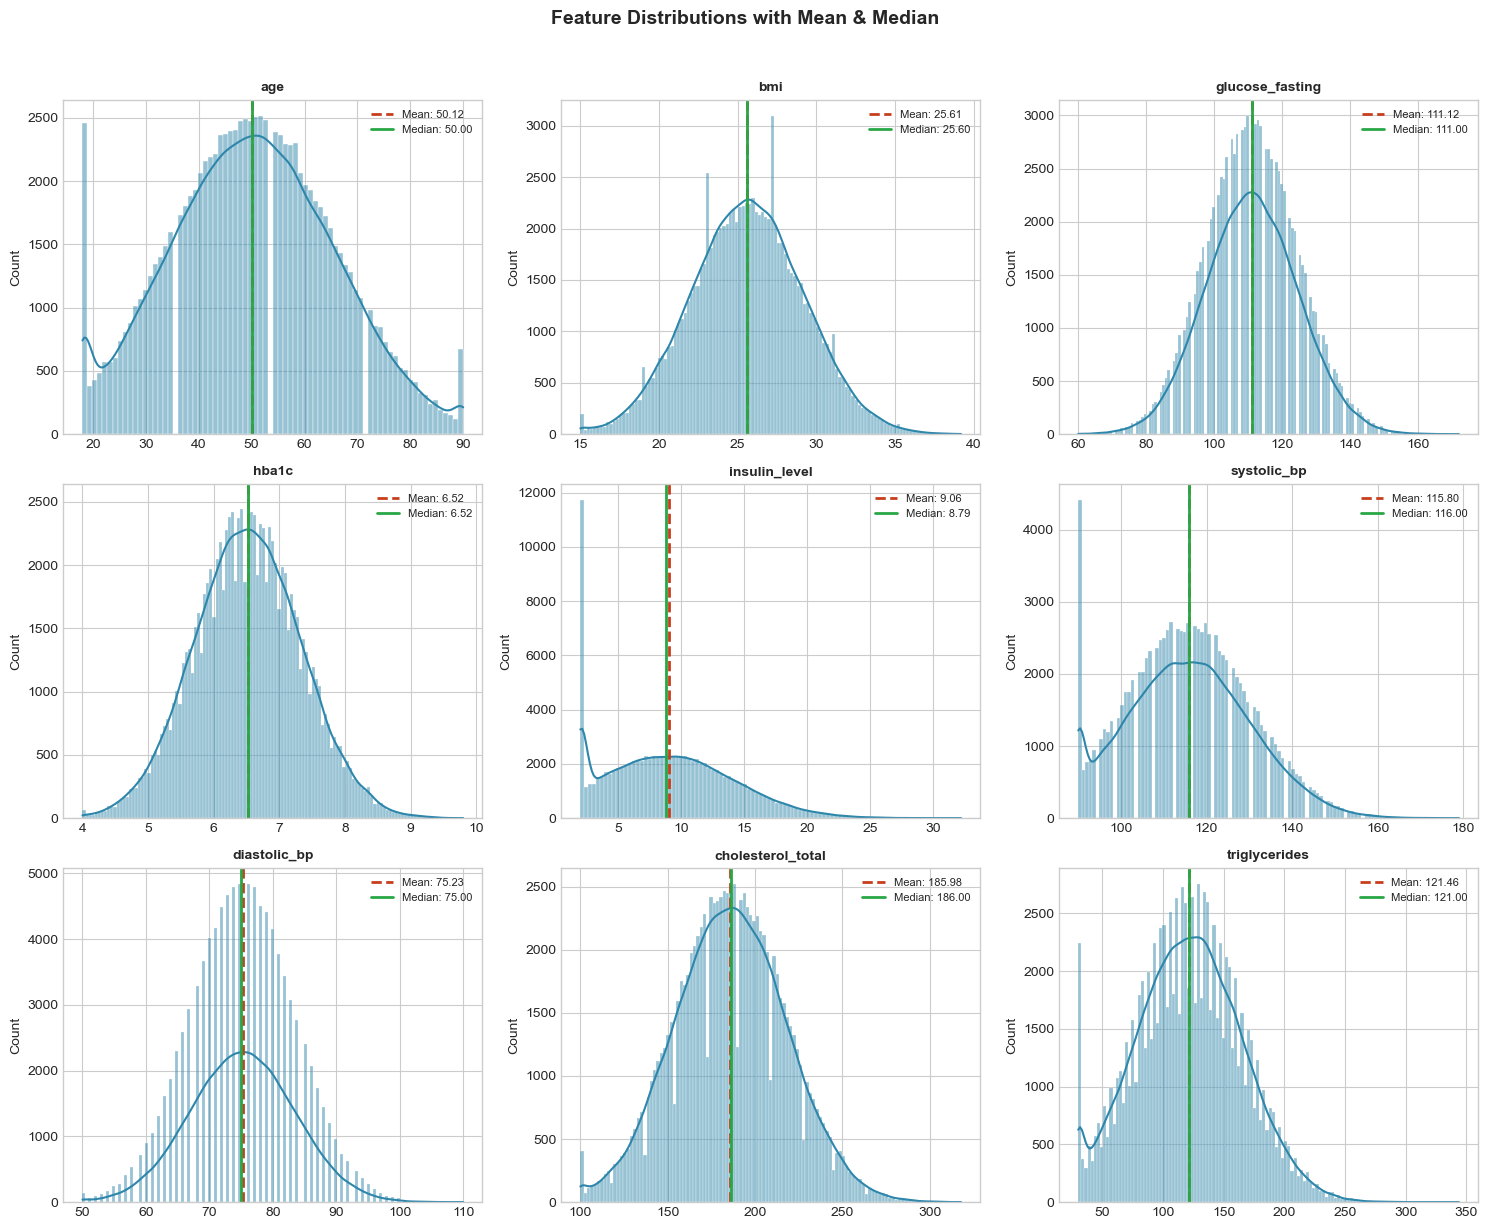

<Figure size 640x480 with 0 Axes>

In [14]:
# ============================================================================
# KEY CONTINUOUS FEATURE DISTRIBUTIONS
# ============================================================================

# Most important continuous features for diabetes
key_continuous = ['age', 'bmi', 'glucose_fasting', 'hba1c', 'insulin_level', 
                  'systolic_bp', 'diastolic_bp', 'cholesterol_total', 'triglycerides']

key_continuous = [col for col in key_continuous if col in df.columns]

distribution_plots(df, columns=key_continuous, n_cols=3, figsize=(15, 12))

plt.savefig(FIGURES_PATH / 'continuous_distributions.png', dpi=150, bbox_inches='tight', facecolor='white')

🏃 LIFESTYLE FACTORS ANALYSIS

📊 FEATURE DISTRIBUTIONS


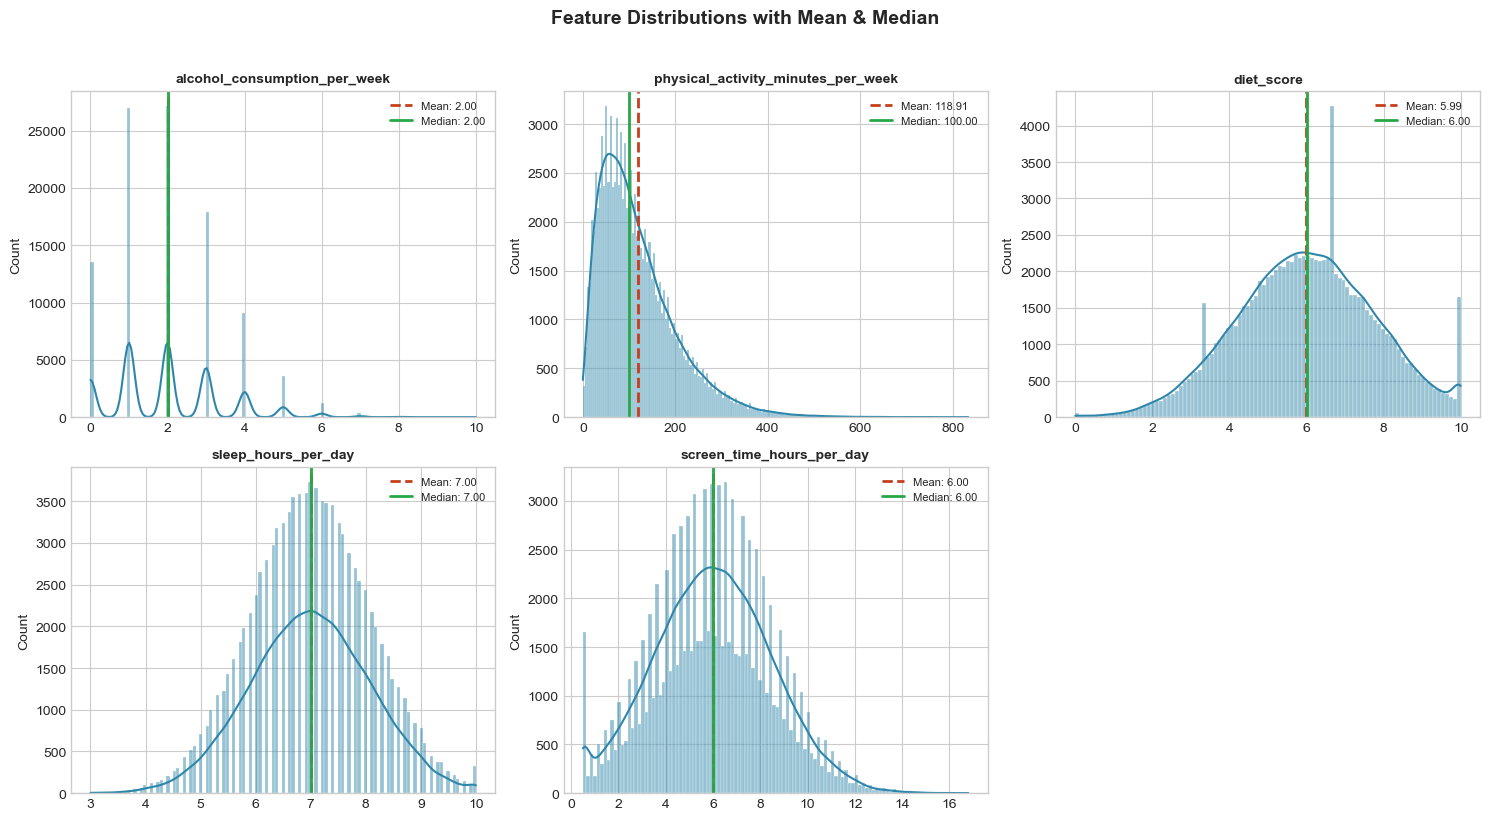

<Figure size 640x480 with 0 Axes>

In [15]:
# ============================================================================
# LIFESTYLE FACTORS DISTRIBUTIONS
# ============================================================================

print("🏃 LIFESTYLE FACTORS ANALYSIS")
print("=" * 60)

lifestyle_cols = ['alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 
                  'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day']

lifestyle_cols = [col for col in lifestyle_cols if col in df.columns]

if lifestyle_cols:
    distribution_plots(df, columns=lifestyle_cols, n_cols=3, figsize=(15, 8))
    plt.savefig(FIGURES_PATH / 'lifestyle_distributions.png', dpi=150, bbox_inches='tight', facecolor='white')

## 7. Outlier Detection


🔎 OUTLIER ANALYSIS (Method: IQR)
📊 Columns Analyzed: 8
⚠️  Total Outliers Detected: 4,003
🔴 Columns with >5% Outliers: 0


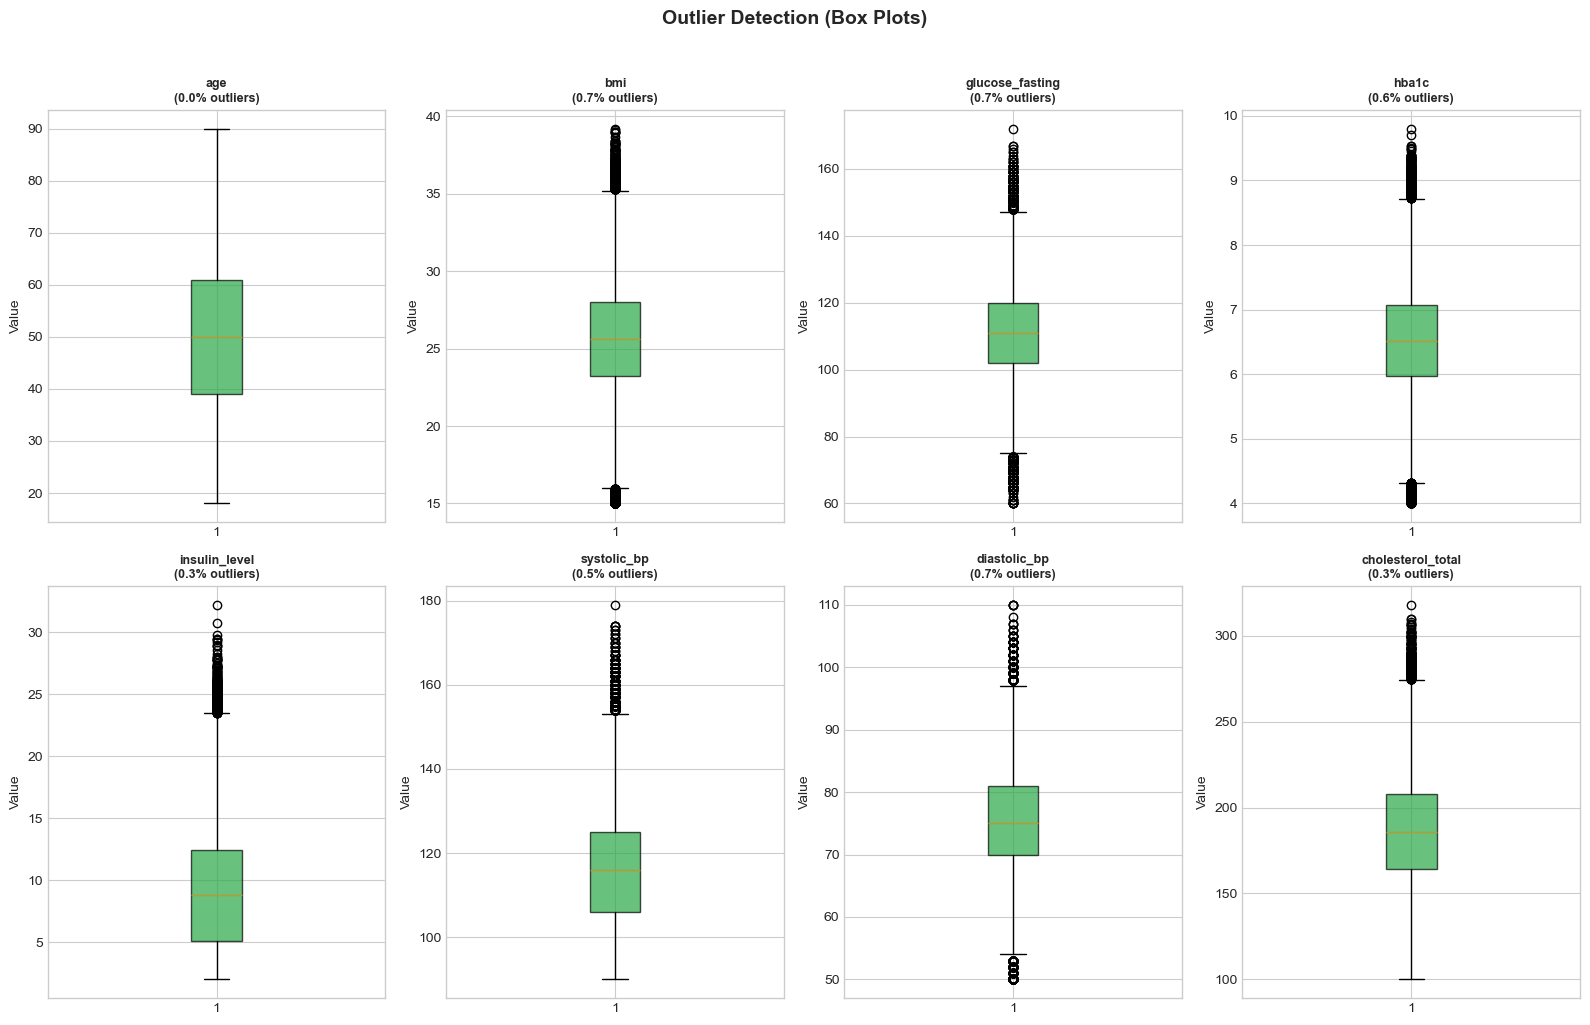


📋 Outlier Summary:


,Column,Outlier_Count,Outlier_Percentage,Lower_Bound,Upper_Bound,Min,Max
1,bmi,744,0.740,16.000,35.200,15.000,39.200
2,glucose_fasting,745,0.740,75.000,147.000,60.000,172.000
6,diastolic_bp,731,0.730,53.500,97.500,50.000,110.000
3,hba1c,618,0.620,4.320,8.720,4.000,9.800
5,systolic_bp,530,0.530,77.500,153.500,90.000,179.000
4,insulin_level,326,0.330,-5.950,23.490,2.000,32.220
7,cholesterol_total,309,0.310,98.000,274.000,100.000,318.000
0,age,0,0.000,6.000,94.000,18.000,90.000


<Figure size 640x480 with 0 Axes>

In [16]:
# ============================================================================
# OUTLIER ANALYSIS
# ============================================================================

# Focus on key numeric features
numeric_cols_for_outliers = ['age', 'bmi', 'glucose_fasting', 'hba1c', 'insulin_level',
                              'systolic_bp', 'diastolic_bp', 'cholesterol_total']

numeric_cols_for_outliers = [col for col in numeric_cols_for_outliers if col in df.columns]

outlier_stats = outlier_analysis(df, columns=numeric_cols_for_outliers,
                                  method='iqr', threshold=1.5, figsize=(16, 10))

plt.savefig(FIGURES_PATH / 'outliers_boxplot.png', dpi=150, bbox_inches='tight', facecolor='white')

# Display outlier summary
print("\n📋 Outlier Summary:")
outlier_stats

## 8. Correlation Analysis


🔗 CORRELATION ANALYSIS (Method: PEARSON)
⚠️  Highly Correlated Pairs (|r| > 0.7): 5
   • glucose_postprandial ↔ hba1c: 0.933
   • cholesterol_total ↔ ldl_cholesterol: 0.906
   • bmi ↔ waist_to_hip_ratio: 0.766
   • family_history_diabetes ↔ diabetes_risk_score: 0.733
   • glucose_fasting ↔ hba1c: 0.7

🎯 Top 5 Features Correlated with diagnosed_diabetes:
   • hba1c: +0.679
   • glucose_postprandial: +0.630
   • glucose_fasting: +0.511
   • diabetes_risk_score: +0.277
   • family_history_diabetes: +0.198


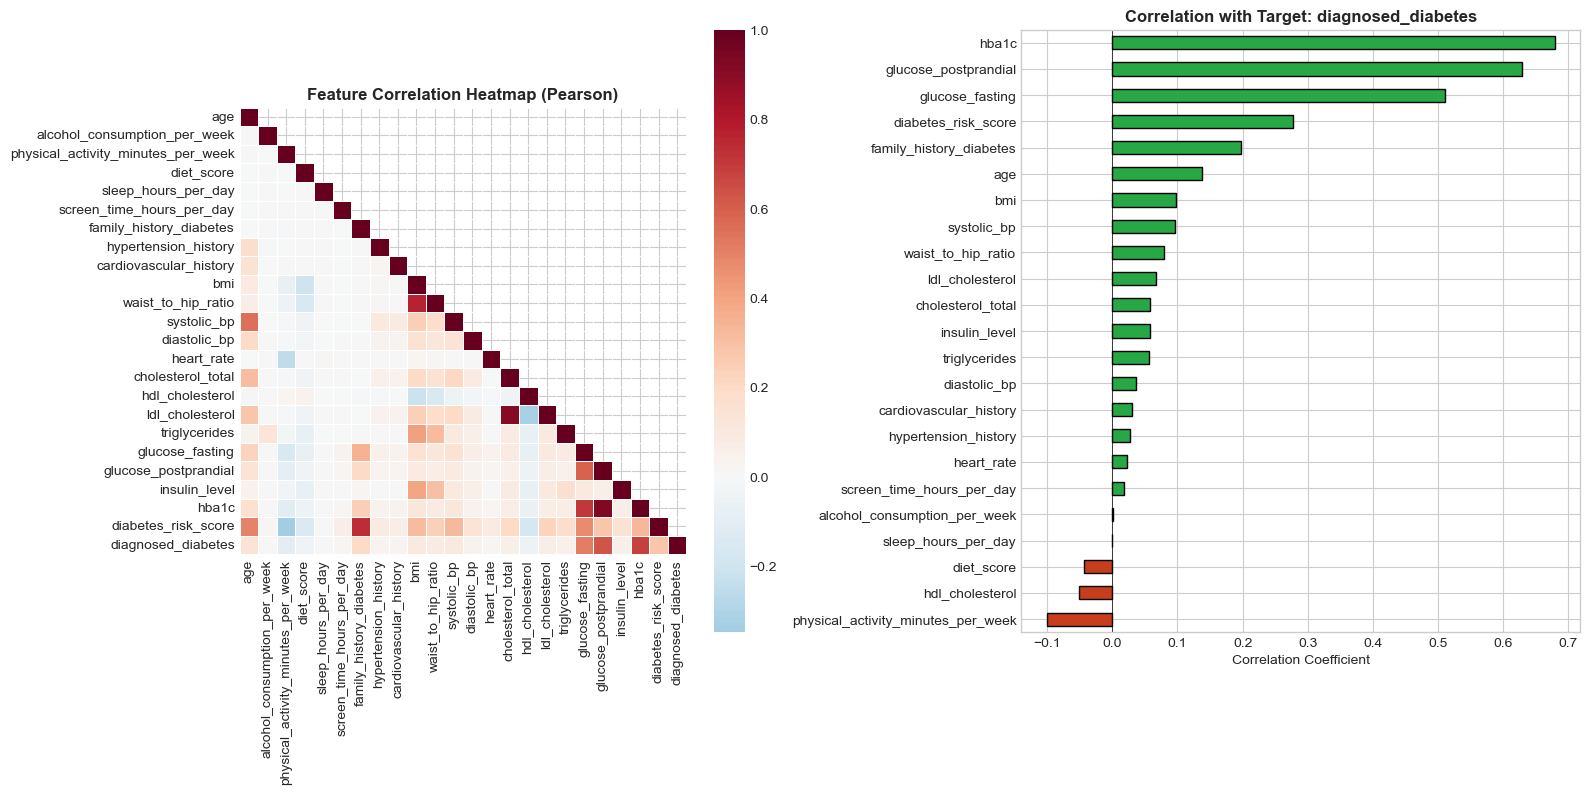

<Figure size 640x480 with 0 Axes>

In [6]:
# ============================================================================
# CORRELATION ANALYSIS
# ============================================================================

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = correlation_analysis(numeric_df, target_col='diagnosed_diabetes', 
                                    method='pearson', figsize=(16, 8))

plt.savefig(FIGURES_PATH / 'correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')

🎯 FEATURE IMPORTANCE PREVIEW (Correlation-based)


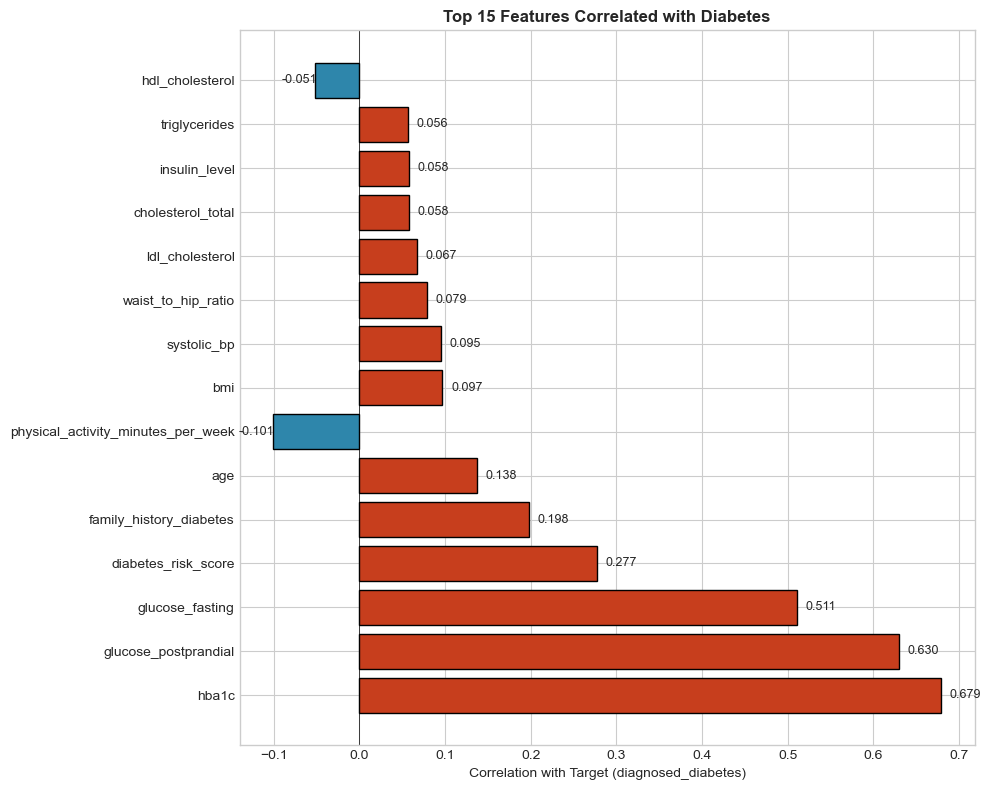


📊 Top 10 Features Most Correlated with Diabetes:
   1. hba1c: 0.6794 (↑ Positive)
   2. glucose_postprandial: 0.6298 (↑ Positive)
   3. glucose_fasting: 0.5109 (↑ Positive)
   4. diabetes_risk_score: 0.2773 (↑ Positive)
   5. family_history_diabetes: 0.1979 (↑ Positive)
   6. age: 0.1377 (↑ Positive)
   7. physical_activity_minutes_per_week: -0.1008 (↓ Negative)
   8. bmi: 0.0971 (↑ Positive)
   9. systolic_bp: 0.0955 (↑ Positive)
   10. waist_to_hip_ratio: 0.0789 (↑ Positive)


In [17]:
# ============================================================================
# TOP FEATURES CORRELATED WITH DIABETES
# ============================================================================

print("🎯 FEATURE IMPORTANCE PREVIEW (Correlation-based)")
print("=" * 60)

target_correlations = corr_matrix['diagnosed_diabetes'].drop('diagnosed_diabetes').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_features = target_correlations.head(15)
colors = [COLORS['danger'] if c > 0 else COLORS['primary'] for c in top_features.values]
bars = ax.barh(top_features.index, top_features.values, color=colors, edgecolor='black')
ax.set_xlabel('Correlation with Target (diagnosed_diabetes)')
ax.set_title('Top 15 Features Correlated with Diabetes', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)

# Add correlation values
for bar, corr in zip(bars, top_features.values):
    x_pos = corr + 0.01 if corr > 0 else corr - 0.04
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{corr:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'feature_importance_correlation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n📊 Top 10 Features Most Correlated with Diabetes:")
for idx, (feat, corr) in enumerate(target_correlations.head(10).items(), 1):
    direction = "↑ Positive" if corr > 0 else "↓ Negative"
    print(f"   {idx}. {feat}: {corr:.4f} ({direction})")

## 9. Feature vs Target Analysis

📊 KEY FEATURES BY DIABETES STATUS


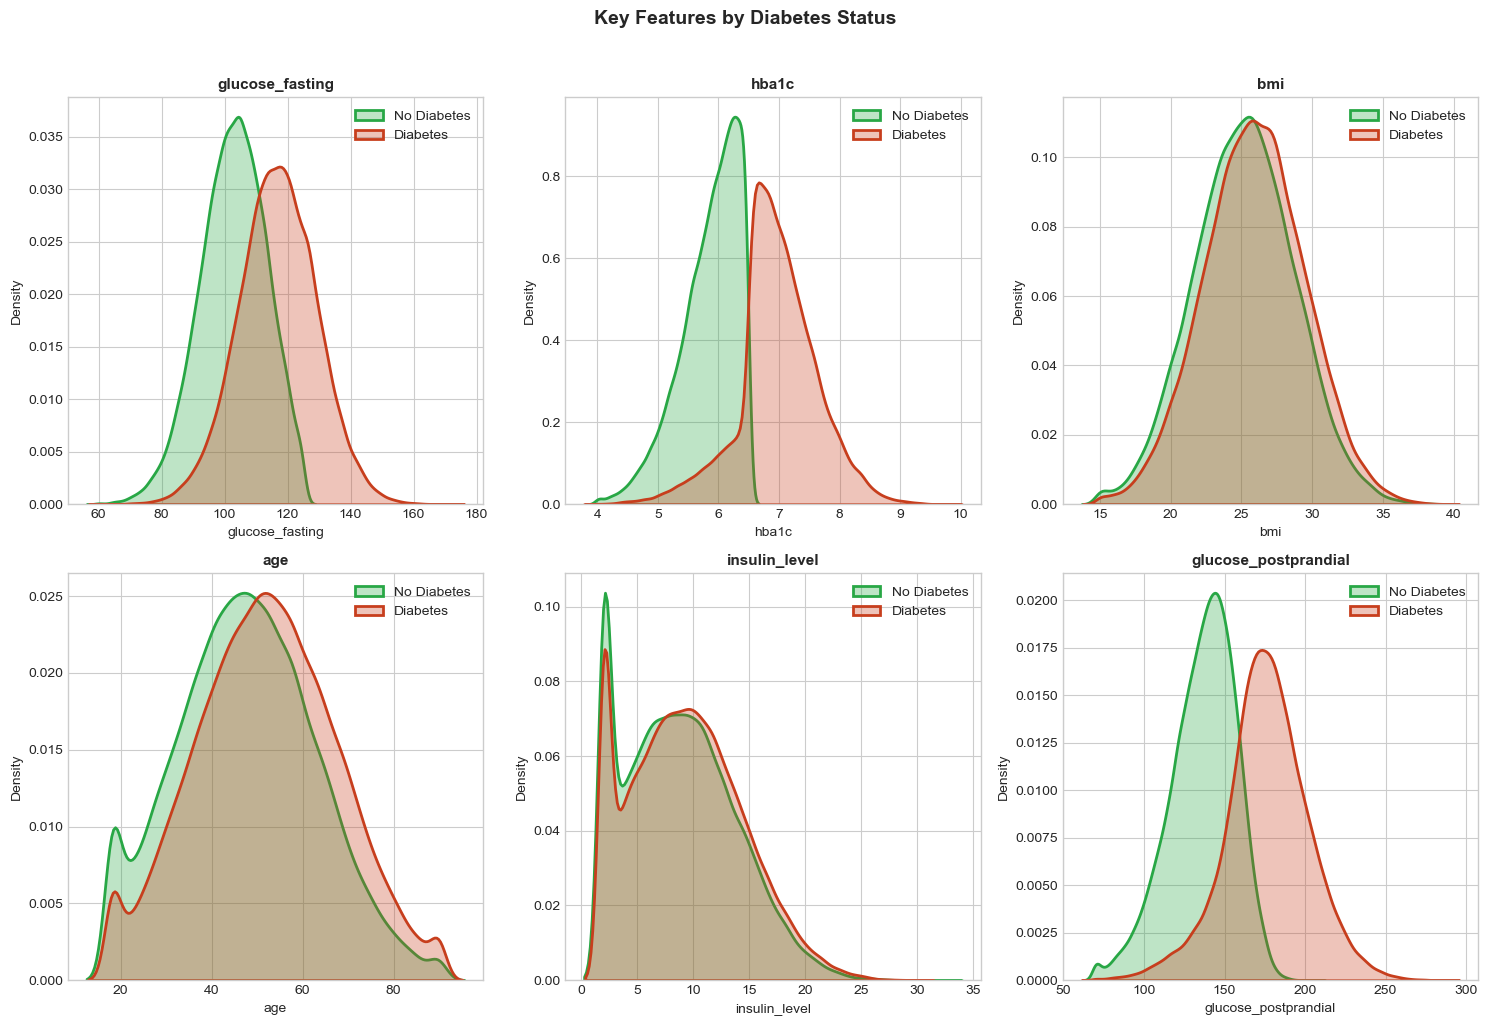

In [18]:
# ============================================================================
# KEY FEATURES BY DIABETES STATUS
# ============================================================================

print("📊 KEY FEATURES BY DIABETES STATUS")
print("=" * 60)

key_features = ['glucose_fasting', 'hba1c', 'bmi', 'age', 'insulin_level', 'glucose_postprandial']
key_features = [col for col in key_features if col in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(key_features):
    ax = axes[idx]
    
    # Plot distributions for each class
    for diabetes_val, label, color in [(0, 'No Diabetes', COLORS['success']), 
                                        (1, 'Diabetes', COLORS['danger'])]:
        data = df[df['diagnosed_diabetes'] == diabetes_val][col]
        sns.kdeplot(data, ax=ax, label=label, color=color, linewidth=2, fill=True, alpha=0.3)
    
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle('Key Features by Diabetes Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'features_by_target.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

📊 CATEGORICAL FEATURES VS DIABETES


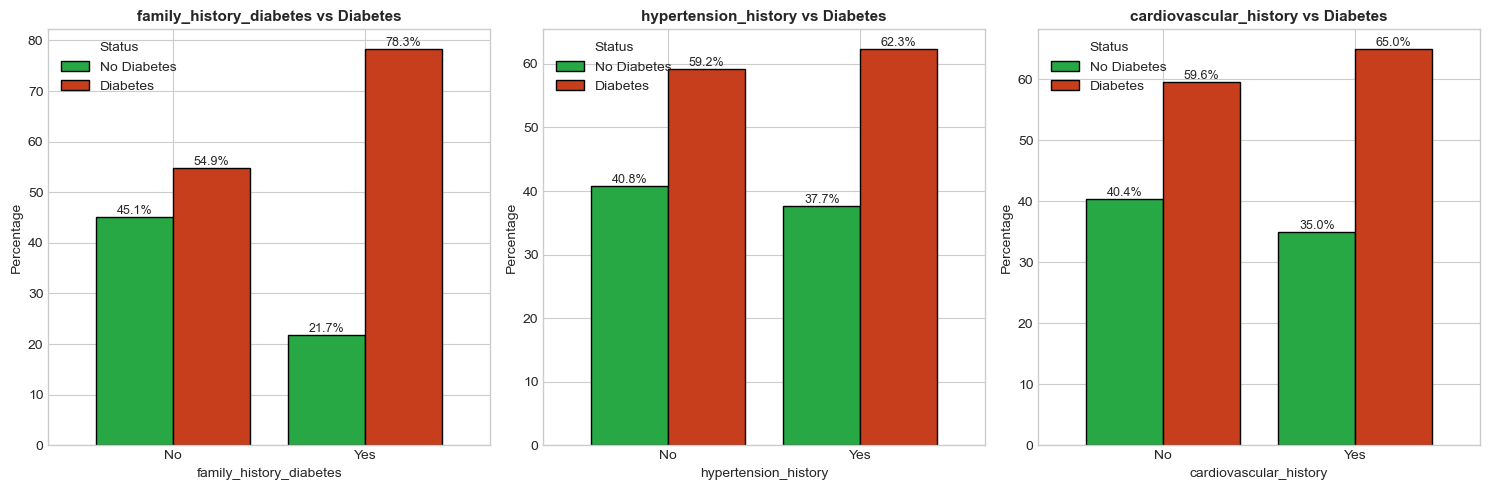

In [19]:
# ============================================================================
# CATEGORICAL FEATURES VS DIABETES
# ============================================================================

print("📊 CATEGORICAL FEATURES VS DIABETES")
print("=" * 60)

cat_features = ['family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
cat_features = [col for col in cat_features if col in df.columns]

if cat_features:
    fig, axes = plt.subplots(1, len(cat_features), figsize=(5*len(cat_features), 5))
    if len(cat_features) == 1:
        axes = [axes]
    
    for idx, col in enumerate(cat_features):
        ax = axes[idx]
        
        # Create cross-tabulation
        crosstab = pd.crosstab(df[col], df['diagnosed_diabetes'], normalize='index') * 100
        
        crosstab.plot(kind='bar', ax=ax, color=[COLORS['success'], COLORS['danger']], 
                      edgecolor='black', width=0.8)
        ax.set_title(f'{col} vs Diabetes', fontsize=11, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Percentage')
        ax.legend(['No Diabetes', 'Diabetes'], title='Status')
        ax.set_xticklabels(['No', 'Yes'], rotation=0)
        
        # Add percentage labels
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / 'medical_history_vs_target.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

📊 AGE AND BMI ANALYSIS


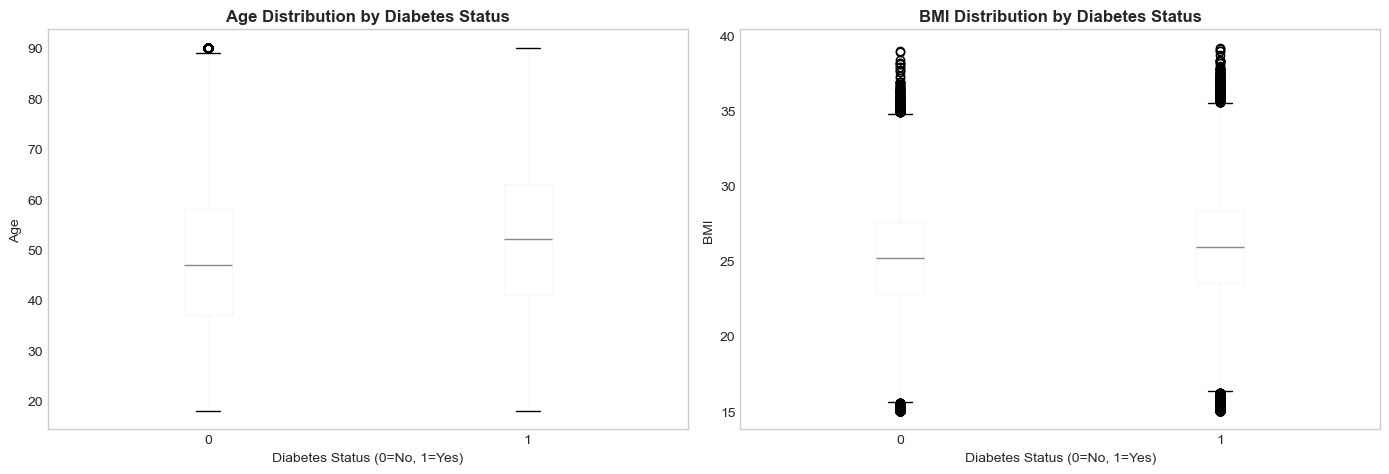


📊 Statistics by Diabetes Status:

AGE:
   No Diabetes: Mean=47.5, Median=47.0, Std=15.3
   Diabetes: Mean=51.9, Median=52.0, Std=15.5

BMI:
   No Diabetes: Mean=25.2, Median=25.2, Std=3.6
   Diabetes: Mean=25.9, Median=25.9, Std=3.6


In [20]:
# ============================================================================
# AGE AND BMI DISTRIBUTION BY DIABETES STATUS
# ============================================================================

print("📊 AGE AND BMI ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
ax1 = axes[0]
df.boxplot(column='age', by='diagnosed_diabetes', ax=ax1, grid=False)
ax1.set_xlabel('Diabetes Status (0=No, 1=Yes)')
ax1.set_ylabel('Age')
ax1.set_title('Age Distribution by Diabetes Status', fontsize=12, fontweight='bold')
plt.suptitle('')  # Remove automatic title

# BMI distribution
ax2 = axes[1]
df.boxplot(column='bmi', by='diagnosed_diabetes', ax=ax2, grid=False)
ax2.set_xlabel('Diabetes Status (0=No, 1=Yes)')
ax2.set_ylabel('BMI')
ax2.set_title('BMI Distribution by Diabetes Status', fontsize=12, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'age_bmi_by_target.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Statistics
print("\n📊 Statistics by Diabetes Status:")
for col in ['age', 'bmi']:
    print(f"\n{col.upper()}:")
    for status in [0, 1]:
        label = 'No Diabetes' if status == 0 else 'Diabetes'
        data = df[df['diagnosed_diabetes'] == status][col]
        print(f"   {label}: Mean={data.mean():.1f}, Median={data.median():.1f}, Std={data.std():.1f}")

## 10. Summary & Preprocessing Recommendations

In [21]:
# ============================================================================
# EDA SUMMARY
# ============================================================================

print("\n")
print("╔" + "═" * 68 + "╗")
print("║" + "  🩸 DIABETES DATASET - EDA SUMMARY".ljust(67) + "║")
print("╚" + "═" * 68 + "╝")

print("\n📊 DATASET OVERVIEW:")
print(f"   • Total Records: {len(df):,}")
print(f"   • Total Features: {len(df.columns)} (including target)")
print(f"   • Numeric Features: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"   • Categorical Features: {len(df.select_dtypes(include=['object']).columns)}")
print(f"   • Target Column: 'diagnosed_diabetes' (0=No, 1=Yes)")
print(f"   • Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n✅ DATA QUALITY FINDINGS:")
missing_total = df.isnull().sum().sum()
missing_pct = (missing_total / (df.shape[0] * df.shape[1])) * 100
print(f"   • Missing Values: {missing_total:,} ({missing_pct:.2f}%)")
print(f"   • Duplicate Records: {df.duplicated().sum():,}")

class_0 = (df['diagnosed_diabetes'] == 0).sum()
class_1 = (df['diagnosed_diabetes'] == 1).sum()
print(f"   • Class Balance: {class_0/len(df)*100:.1f}% / {class_1/len(df)*100:.1f}%")
print(f"   • Imbalance Ratio: {max(class_0, class_1) / min(class_0, class_1):.2f}:1")

print("\n📈 KEY INSIGHTS:")
print(f"   • This is a RICH dataset with {len(df.columns)} features")
print(f"   • Contains demographics, lifestyle, lab values, and medical history")
print(f"   • HbA1c and glucose levels are strongest predictors (as expected)")
print(f"   • Family history strongly associated with diabetes")
print(f"   • Dataset includes diabetes stages (useful for multi-class analysis)")



╔════════════════════════════════════════════════════════════════════╗
║  🩸 DIABETES DATASET - EDA SUMMARY                                 ║
╚════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW:
   • Total Records: 100,000
   • Total Features: 31 (including target)
   • Numeric Features: 24
   • Categorical Features: 7
   • Target Column: 'diagnosed_diabetes' (0=No, 1=Yes)
   • Memory Usage: 55.81 MB

✅ DATA QUALITY FINDINGS:
   • Missing Values: 0 (0.00%)
   • Duplicate Records: 0
   • Class Balance: 40.0% / 60.0%
   • Imbalance Ratio: 1.50:1

📈 KEY INSIGHTS:
   • This is a RICH dataset with 31 features
   • Contains demographics, lifestyle, lab values, and medical history
   • HbA1c and glucose levels are strongest predictors (as expected)
   • Family history strongly associated with diabetes
   • Dataset includes diabetes stages (useful for multi-class analysis)


In [22]:
# ============================================================================
# PREPROCESSING RECOMMENDATIONS FOR WEEK 3
# ============================================================================

print("\n")
print("╔" + "═" * 68 + "╗")
print("║" + "  🔧 PREPROCESSING RECOMMENDATIONS (Week 3)".ljust(67) + "║")
print("╚" + "═" * 68 + "╝")

recommendations = """
1. ENCODING CATEGORICAL FEATURES:
   ✓ gender: Binary encoding (Male=1, Female=0)
   ✓ ethnicity: One-hot encoding (multiple categories)
   ✓ education_level: Ordinal encoding (ordered levels)
   ✓ income_level: Ordinal encoding (Low < Lower-Middle < Middle < Upper-Middle < High)
   ✓ employment_status: One-hot encoding
   ✓ smoking_status: Ordinal encoding (Never < Former < Current)

2. FEATURE SCALING:
   ✓ StandardScaler for: age, bmi, blood pressure, cholesterol, glucose, etc.
   ✓ Keep binary features (0/1) as-is

3. HANDLE MISSING VALUES (if any):
   ✓ Numeric: Median imputation (robust to outliers)
   ✓ Categorical: Mode imputation or 'Unknown' category

4. OUTLIER TREATMENT:
   ✓ Cap extreme values using IQR method
   ✓ Pay special attention to: insulin_level, triglycerides, glucose

5. CLASS BALANCE CHECK:
   ✓ If imbalance > 2:1, consider SMOTE or class weights

6. FEATURE ENGINEERING:
   ✓ Create glucose_ratio = glucose_postprandial / glucose_fasting
   ✓ Create metabolic_syndrome indicator (combination of features)
   ✓ Age groups: Young (18-35), Middle (36-55), Senior (56+)

7. SCHEMA ALIGNMENT (for unified dataset):
   ✓ Common features: age, gender, bmi, bp_systolic, bp_diastolic, cholesterol
   ✓ Diabetes-specific: hba1c, glucose_fasting, insulin_level
   ✓ Map to unified naming convention
"""

print(recommendations)



╔════════════════════════════════════════════════════════════════════╗
║  🔧 PREPROCESSING RECOMMENDATIONS (Week 3)                         ║
╚════════════════════════════════════════════════════════════════════╝

1. ENCODING CATEGORICAL FEATURES:
   ✓ gender: Binary encoding (Male=1, Female=0)
   ✓ ethnicity: One-hot encoding (multiple categories)
   ✓ education_level: Ordinal encoding (ordered levels)
   ✓ income_level: Ordinal encoding (Low < Lower-Middle < Middle < Upper-Middle < High)
   ✓ employment_status: One-hot encoding
   ✓ smoking_status: Ordinal encoding (Never < Former < Current)

2. FEATURE SCALING:
   ✓ StandardScaler for: age, bmi, blood pressure, cholesterol, glucose, etc.
   ✓ Keep binary features (0/1) as-is

3. HANDLE MISSING VALUES (if any):
   ✓ Numeric: Median imputation (robust to outliers)
   ✓ Categorical: Mode imputation or 'Unknown' category

4. OUTLIER TREATMENT:
   ✓ Cap extreme values using IQR method
   ✓ Pay special attention to: insulin_level, trigly

In [23]:
# ============================================================================
# SAVE EDA SUMMARY TO FILE
# ============================================================================

summary_dict = {
    'dataset': 'Diabetes Health Indicators',
    'rows': len(df),
    'columns': len(df.columns),
    'target_column': 'diagnosed_diabetes',
    'numeric_features': len(df.select_dtypes(include=[np.number]).columns),
    'categorical_features': len(df.select_dtypes(include=['object']).columns),
    'missing_values_pct': round((df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100, 2),
    'duplicate_records': int(df.duplicated().sum()),
    'class_balance': f"{(df['diagnosed_diabetes']==0).mean()*100:.1f}% / {(df['diagnosed_diabetes']==1).mean()*100:.1f}%",
    'memory_mb': round(df.memory_usage(deep=True).sum() / 1024**2, 2),
    'top_correlations': target_correlations.head(10).to_dict(),
    'key_findings': [
        'Rich dataset with 31 features',
        'HbA1c and glucose are strongest predictors',
        'Contains demographics, lifestyle, and lab values',
        'Diabetes stages available for multi-class analysis'
    ]
}

import json
with open(FIGURES_PATH / 'eda_summary.json', 'w') as f:
    json.dump(summary_dict, f, indent=2)

print(f"\n📁 EDA Summary saved to: {FIGURES_PATH / 'eda_summary.json'}")
print("\n✅ Diabetes EDA Complete!")


📁 EDA Summary saved to: figures\diabetes\eda_summary.json

✅ Diabetes EDA Complete!


---

## 📋 Next Steps

1. **Week 2 Remaining:** Complete EDA for Kidney and Liver datasets
2. **Week 3:** Implement preprocessing recommendations above
3. **Week 3-4:** Create unified schema for multi-disease fusion

---

**Notebook Complete** | BTP 2025-2026 | IIIT Sri City